In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from collections import namedtuple

## Model

In [2]:
## Our model function
def vdp(t, state, model_parameters):
    """ van der Pol model

    Parameters
    ----------

      - t : scalar
        Time point.

      - state : 2-element iterable
        Values of x and y (i.e. van der Pol's variables) at which to evaluate
        the derivatives.

      - model_parameters : collections.namedtuple
        Values of model parameters. For van der Pol model, there's only one
        parameter, mu.

    Returns
    -------

      - 2-element tuple
        Values of the derivatives dx/dt, dy/dt

    """

    x, y = state

    dxdt = y
    dydt = model_parameters.mu * (1 - x**2) * y - x

    return dxdt, dydt

# Stiff problem

## Model parameters

In [3]:
ParamSet = namedtuple('params', 'mu')

params_stiff = ParamSet(mu = 1000)
params_stiff.mu

1000

In [4]:
state_initial = (2, 0)

t_span = (0, 3000) # Stiff Van der Pol oscillator

In [35]:
solution_stif = solve_ivp(vdp, [0,4000], state_initial, method='BDF', args=(ParamSet(mu = 1000),), t_eval=np.arange(0,4000,1))
solution_nstf = solve_ivp(vdp, [0,18], state_initial, args=(ParamSet(mu = 2),), t_eval=np.arange(0,18,0.01))

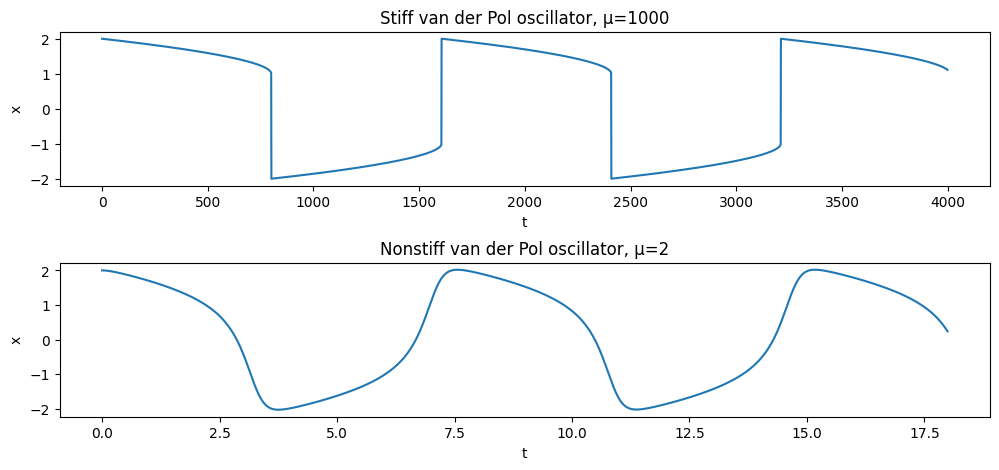

In [46]:
f, (ax,ax1) = plt.subplots(2,1,figsize=(12,5))
plt.subplots_adjust(hspace=0.5)

ax.plot(solution_stif.t, solution_stif.y[0])
ax1.plot(solution_nstf.t, solution_nstf.y[0])
ax.set_title(f'Stiff van der Pol oscillator, µ={1000}')
ax1.set_title(f'Nonstiff van der Pol oscillator, µ={2}')

for x in [ax,ax1]:
  x.set_xlabel('t')
  x.set_ylabel('x')

# plt.savefig('vdp_stiff_nonstiff.pdf',bbox_inches='tight')

## Stiff ODEs

When numerically solving an ODE, we want our integrating algorithm to use large step size when the solution changes slowly, and small step size when the solution changes fast. This keeps the computational time short yet doesn't sacrifice the precision.

Stiff ODEs trigger certain integrating algorithms to use very small step size even when the solution changes slowly, making the computation unncecessary slow. The cause of the problem is in the ODE itself (https://en.wikipedia.org/wiki/Stiff_equation). To solve stiff ODEs, one uses algorithms designed to solve them.

## Here's what scipy's documentation says about choosing solver method (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html):

"Explicit Runge-Kutta methods (‘RK23’, ‘RK45’, ‘DOP853’) should be used for non-stiff problems and implicit methods (‘Radau’, ‘BDF’) for stiff problems [9]. Among Runge-Kutta methods, ‘DOP853’ is recommended for solving with high precision (low values of rtol and atol).

If not sure, first try to run ‘RK45’. If it makes unusually many iterations, diverges, or fails, your problem is likely to be stiff and you should use ‘Radau’ or ‘BDF’. ‘LSODA’ can also be a good universal choice, but it might be somewhat less convenient to work with as it wraps old Fortran code."

## Solve van der Pol model using an algorithm for non-stiff and for stiff ODEs

In [ ]:
%time solution_rk45 = solve_ivp(vdp, t_span, state_initial, method='RK45', args=(params_stiff,)) # RK45 performs poorly with stiff ODEs — takes a lot of time

CPU times: user 2min 37s, sys: 812 ms, total: 2min 38s
Wall time: 2min 41s


In [ ]:
%time solution_bdf = solve_ivp(vdp, t_span, state_initial, method='BDF', args=(params_stiff,)) # BDF is for stiff ODEs - faster

CPU times: user 141 ms, sys: 0 ns, total: 141 ms
Wall time: 148 ms


### Plot the results

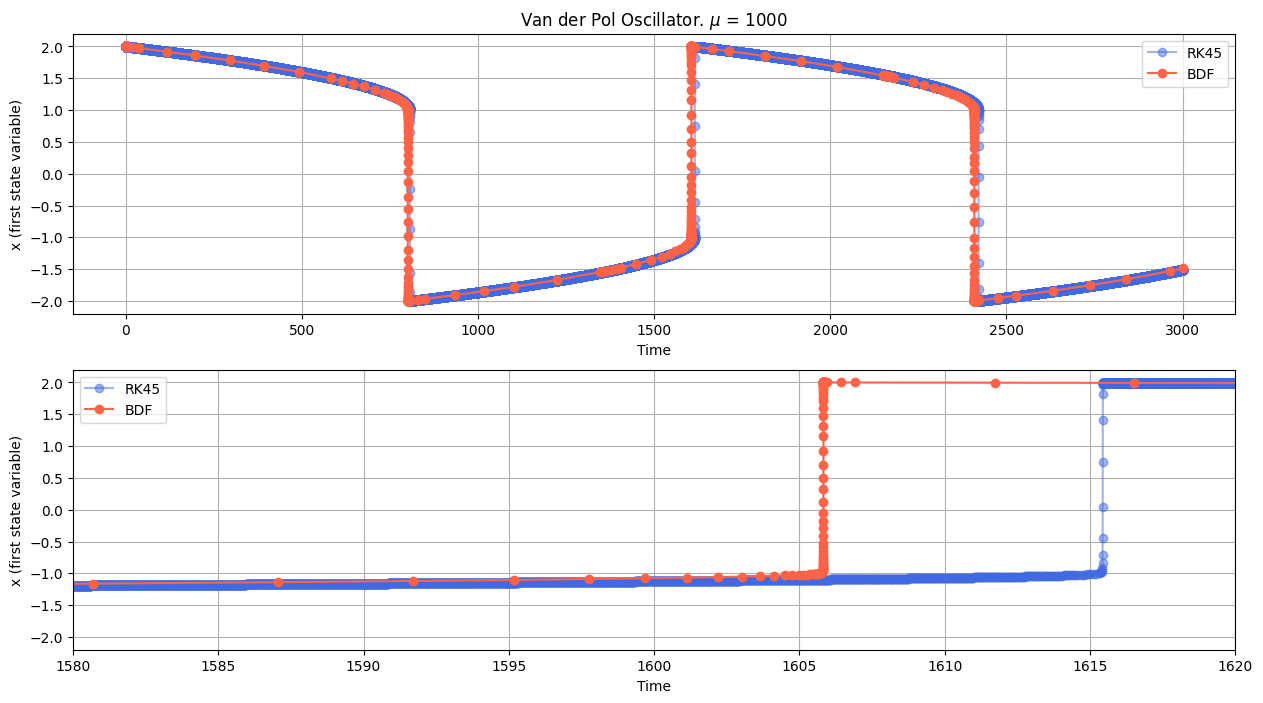

In [ ]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(15, 8))

ax.plot(solution_rk45.t, solution_rk45.y[0], 'o-', label='RK45', alpha=0.5, c='royalblue')
ax.plot(solution_bdf.t, solution_bdf.y[0], 'o-', label='BDF', c='tomato')
ax.grid()
ax.set_title(f'Van der Pol Oscillator. $\mu$ = {params_stiff.mu}')

ax1.plot(solution_rk45.t, solution_rk45.y[0], 'o-', label='RK45', alpha=0.5, c='royalblue')
ax1.plot(solution_bdf.t, solution_bdf.y[0], 'o-', label='BDF', c='tomato')
ax1.grid()
ax1.set_xlim(1580, 1620)

for x in [ax,ax1]:

  x.set_xlabel('Time')
  x.set_ylabel('x (first state variable)')
  x.legend()

Notice from the lower panel of the figure above, where each dot shows a solution value:


*   The number of blue dots (RK45 solver) is so large, that we cannot see individual dots between Time=1580 and 1615. We don't want this because the solution changes very slow in this interval, and can be approximated by smaller number of dots, saving our time. The number of red dots (BDF solver) in the similar time interval (1580 to 1605) is much smaller: we can see individual dots.
*   The blue curve increases later than the red curve.

This illustrates that using a non-stiff algorithm for solving a stiff ODE may result in (a) wasted time, (b) erroneous results.



# van der Pol system is non-Stiff when mu is small

## Model parameters

In [ ]:
params_nonstiff = ParamSet(mu = 1)

state_initial = (2, 0)
t_span = (0, 3000)

In [ ]:
%time solution_rk45 = solve_ivp(vdp, t_span, state_initial, method='RK45', args=(params_nonstiff,))

CPU times: user 787 ms, sys: 11.9 ms, total: 798 ms
Wall time: 797 ms


In [ ]:
%time solution_bdf = solve_ivp(vdp, t_span, state_initial, method='BDF', args=(params_nonstiff,))

CPU times: user 7.14 s, sys: 4.97 ms, total: 7.14 s
Wall time: 7.19 s


### Plot the results

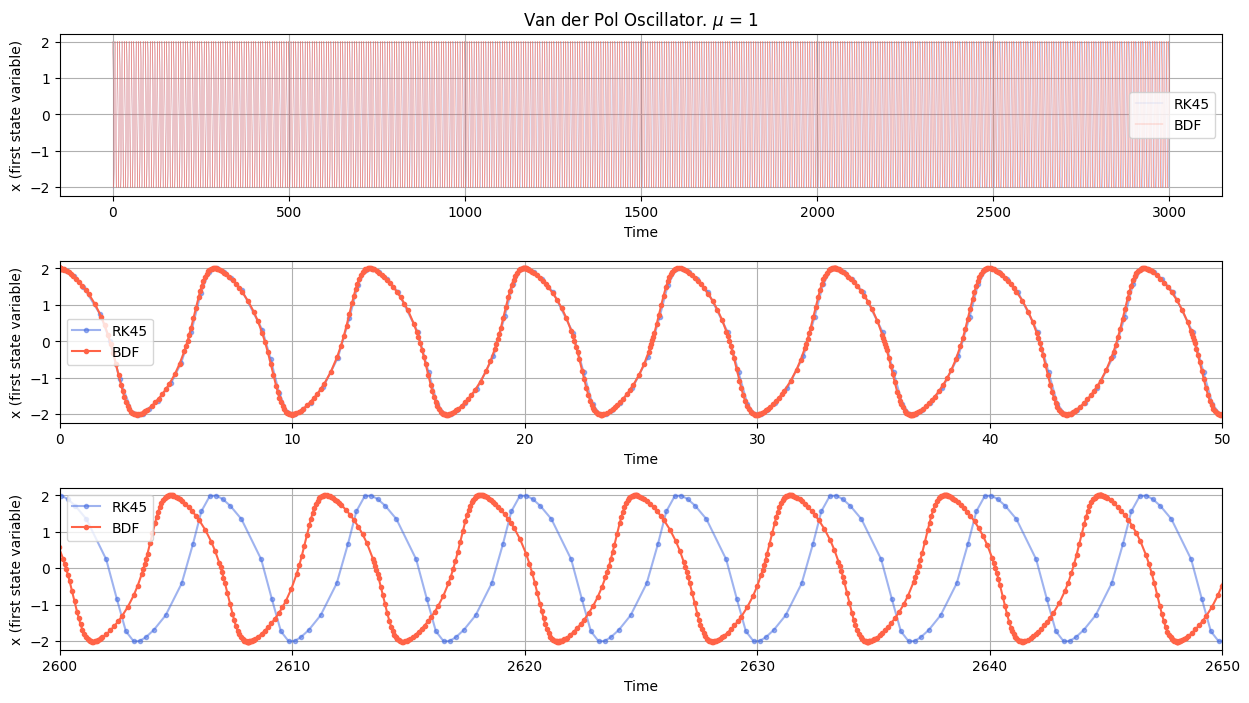

In [ ]:
f, (ax,ax1,ax2) = plt.subplots(3,1, figsize=(15, 8))

plt.subplots_adjust(hspace=0.4)

ax.plot(solution_rk45.t, solution_rk45.y[0], '-', lw=0.2, label='RK45', alpha=0.5, c='royalblue')
ax.plot(solution_bdf.t, solution_bdf.y[0], '-', lw=0.2, label='BDF', c='tomato')
ax.grid()
ax.set_title(f'Van der Pol Oscillator. $\mu$ = {params_nonstiff.mu}')

ax1.plot(solution_rk45.t, solution_rk45.y[0], '.-', label='RK45', alpha=0.5, c='royalblue')
ax1.plot(solution_bdf.t, solution_bdf.y[0], '.-', label='BDF', c='tomato')
ax1.grid()
ax1.set_xlim(0, 50)

ax2.plot(solution_rk45.t, solution_rk45.y[0], '.-', label='RK45', alpha=0.5, c='royalblue')
ax2.plot(solution_bdf.t, solution_bdf.y[0], '.-', label='BDF', c='tomato')
ax2.grid()
ax2.set_xlim(2600, 2650)

for x in [ax,ax1, ax2]:

  x.set_xlabel('Time')
  x.set_ylabel('x (first state variable)')
  x.legend()

When van der Pol system is non-stiff (mu is small), we can see that both algorithms, RK45 (for non-stiff) and BDF (for stiff), can integrate the system relatively fast (within a few seconds), although BDF takes 10 times longer than RK45.

We can also see that the solutions obtained with either algorithms look very similar at early times (middle panel in the figure above). Howeve, the solutions differ clearly at later times (lower panel): The RK45-solution is delayed relative to the BDF-solution.